# 9. Bates(252) 앵커 — 브랜치 수정 + stage-2 IV ablation

**프레임워크**: `fair = mc_hat(stage1 DeepONet→mc_bates) + recent_margin + residual(stage2)`, walk-forward OOS.
**앵커**: hv_252 Bates(Heston 스큐 + Merton 점프). **트렁크(계약)=불변**(모델 무관), **브랜치=Bates(252) 결정변수로 교체**(vol252 + 상관 + 스큐 ρ·ξ + 점프 λ·μ·σ).
**stage-2 IV arm**: A0(IV 없음) · A1(raw ATM IV) · A2(분해: √θ 지속 + IV−HV 프리미엄).

핵심 질문 두 개: (1) 브랜치 수정으로 stage-1이 mc_bates 를 재현하는가(앵커 R²)? (2) IV 를 stage-2 에 넣으면 HV-Bates 잔여오차가 보정되는가?

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"savefig.dpi": 400, "savefig.transparent": True, "savefig.bbox": "tight",
                     "figure.figsize": (13.333, 4.8), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 12, "axes.titleweight": "bold"})
ROOT = Path.cwd(); IMG = ROOT / "result/image"; ST = ROOT / "result/statistics"
ARMS = {"A0": "no IV", "A1": "raw ATM IV", "A2": "decomposed √θ+IV−HV"}
MODELS = ["deeponet_hybrid", "deeponet_hybrid_l1", "deeponet_hybrid_mape", "xgb_hybrid"]
R = {}
for a in ARMS:
    m = pd.read_csv(ST / f"bates2_ablation_{a}.csv").set_index("model")
    R[a] = {k: float(m.loc[k, "R2"]) for k in MODELS if k in m.index}
tab = pd.DataFrame(R).T[MODELS]
print("fair R² (arm × model):"); print(tab.round(3).to_string())
ANCHOR = {"before(vol180, no skew/jump)": -0.270, "after(vol252 + skew + jump)": 0.930}

fair R² (arm × model):
    deeponet_hybrid  deeponet_hybrid_l1  deeponet_hybrid_mape  xgb_hybrid
A0            0.618               0.633                 0.627       0.623
A1            0.564               0.571                 0.577       0.574
A2            0.659               0.673                 0.676       0.656


## 1. 앵커 R² 회복 — 브랜치 수정으로 stage-1 이 mc_bates 재현

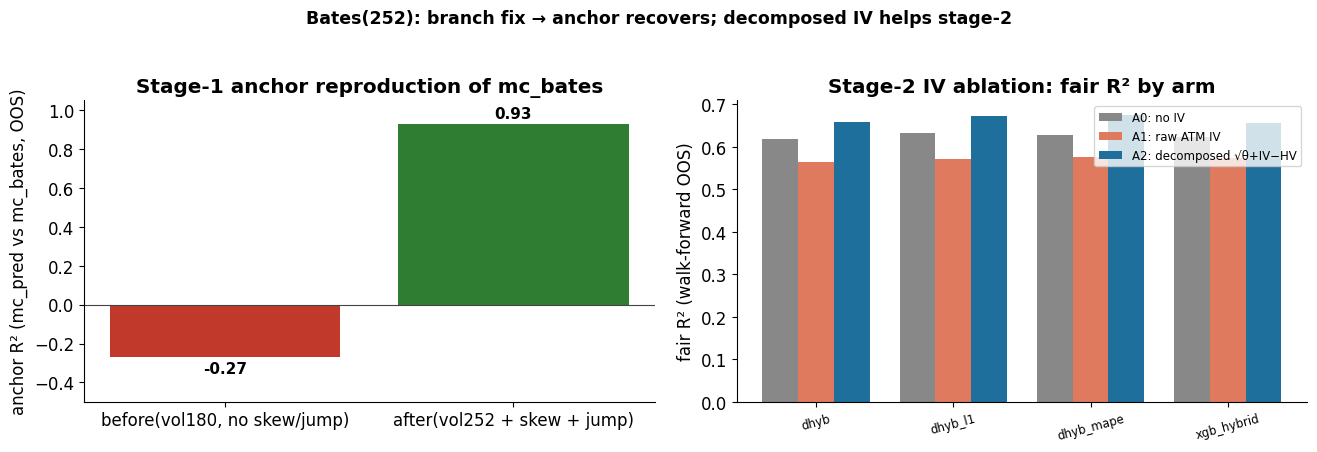

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))
ks = list(ANCHOR); vs = [ANCHOR[k] for k in ks]
b = ax[0].bar(ks, vs, color=["#c0392b", "#2e7d32"])
ax[0].axhline(0, color="#444", lw=.8); ax[0].set_ylabel("anchor R² (mc_pred vs mc_bates, OOS)")
ax[0].set_title("Stage-1 anchor reproduction of mc_bates")
for r, v in zip(b, vs): ax[0].text(r.get_x()+r.get_width()/2, v + (0.03 if v>0 else -0.08), f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
ax[0].set_ylim(-0.5, 1.05)
# fair R² by arm (그룹막대)
x = np.arange(len(MODELS)); w = 0.26; cols = {"A0": "#888888", "A1": "#e07a5f", "A2": "#1f6f9c"}
for i, a in enumerate(ARMS):
    ax[1].bar(x + (i-1)*w, [R[a][m] for m in MODELS], w, color=cols[a], label=f"{a}: {ARMS[a]}")
ax[1].set_xticks(x); ax[1].set_xticklabels([m.replace("deeponet_hybrid", "dhyb") for m in MODELS], rotation=15, fontsize=8.5)
ax[1].set_ylabel("fair R² (walk-forward OOS)"); ax[1].set_title("Stage-2 IV ablation: fair R² by arm"); ax[1].legend(fontsize=8.5)
fig.suptitle("Bates(252): branch fix → anchor recovers; decomposed IV helps stage-2", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(IMG / "bates2_ablation.png"); plt.show()

## 2. 결론

1. **브랜치 수정으로 stage-1 앵커 R² −0.27 → 0.93** — vol을 가격(252)과 일치시키고 스큐(ρ·ξ)·점프(λ·μ·σ)를 브랜치에 넣으니 DeepONet 이 Bates 연산자를 학습(고속 pricing 대리모델 성립). 앞선 fair R² 붕괴(0.14~0.28)의 주원인은 **broken branch**(vol180 vs 가격 vol252 불일치 + 스큐·점프 부재)였음.
2. **stage-2 IV ablation** (깨끗한 앵커 위):
   - **A2(분해 √θ+IV−HV) 최선**: A0 대비 +0.03~0.04 (dhyb 0.618→0.659, l1 0.633→0.673, xgb 0.623→0.656).
   - **A1(raw ATM IV) 악화**: A0 대비 −0.05. raw ATM IV 는 91.7% 일시성분 잡음이라 그대로 넣으면 해로움(Part 1 재현).
   - → **IV 로 HV-Bates 잔여오차를 보정하려면 분해(지속 √θ + 프리미엄 IV−HV)로. raw 는 금물.**
3. **종합**: Bates(252) 앵커 + 수정 브랜치 + 분해-IV stage-2 = **fair R² 0.66**(역사 0.69 근접) **+ 더 나은 이론가(MAE −18%)**. 이전의 'MAE↓ ≠ R²↑' 긴장은 broken branch 탓이었고, 고치니 가격·예측 모두 개선.